<a href="https://colab.research.google.com/github/silprosa/nipe_macho/blob/main/notebooks/potholes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI project

# Potholes Detection

**Updated**: June 2026
**Framework**: Fynesse (Access, Assess, Address)  
**Environment**: colab notebook

This notebook demonstrates the complete Fynesse data analysis pipeline using modern Python development practices.

### **Abstract**

Road potholes pose significant challenges to transportation infrastructure, contributing to vehicle damage, increased maintenance costs, traffic disruptions, and road safety hazards. Traditional road inspection methods rely heavily on manual surveys, which are often time-consuming, labor-intensive, and inefficient for large road networks. This project presents an AI-based pothole detection system utilizing the YOLOv8 object detection framework to automatically identify potholes from road images collected on Kenyan roads.

The system is trained on a custom annotated dataset and evaluated using standard object detection metrics, including precision, recall, and mean Average Precision (mAP). In addition to pothole detection, the project incorporates severity assessment based on pothole dimensions extracted from detection results. Geographical coordinates embedded within image metadata are also utilized to map pothole locations, enabling the creation of an interactive road condition monitoring platform.

The proposed solution demonstrates the potential of combining deep learning and geospatial technologies to support efficient road maintenance planning, improve road safety, and provide a scalable approach to infrastructure monitoring in developing regions.


---
## Setting up the Environment

Before beginning our, we must configure the Google Colab environment.

YOLOv8 requires specific versions of Numpy and Pandas to prevent dependency conflicts with Colab's default pre-installed libraries. The following cell installs the required packages and safely restarts the Colab runtime to apply them.

In [ ]:
!pip install --quiet "numpy==1.26.4" "pandas==2.2.2" "ultralytics==8.2.103" "roboflow" 2>/dev/null
# Restart the Colab runtime automatically so the new Numpy takes effect
import os
os.kill(os.getpid(), 9)

#!pip uninstall -y numpy pandas
#!pip install numpy==1.26.4
#!pip install pandas==2.2.2
#!pip install ultralytics==8.2.103 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.1/875.1 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 83.6 MB/s eta 0:00:00


#### Verify GPU Access
, let's also make sure that we have access to a GPU before we start training the model. Training on a GPU is exponentially faster than on a CPU.

We can use the `nvidia-smi` command to verify our hardware allocation. This command displays the current GPU model, memory usage, and CUDA version.


In [1]:
!nvidia-smi

Tue Jun 16 12:29:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#### Cloning the Project Repository
To utilize our custom Python modules and keep our project organized, we need to pull the latest version of our project repository into the Colab environment.

The following cell performs a fresh clone by first removing any outdated versions of the folder, downloading the latest code from GitHub, and appending the repository to our system path so we can easily import our custom scripts.

In [2]:
# Remove existing repository folder to ensure a clean clone and setup
import shutil
shutil.rmtree("/content/nipe_macho", ignore_errors=True)
# Clone the latest version of the repository from GitHub

!git clone https://github.com/silprosa/nipe_macho.git
import os, subprocess, importlib, sys
sys.path.append("/content/nipe_macho")

Cloning into 'nipe_macho'...
remote: Enumerating objects: 95, done.
remote: Counting objects: 100% (95/95), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 95 (delta 33), reused 22 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (95/95), 3.07 MiB | 6.05 MiB/s, done.
Resolving deltas: 100% (33/33), done.


### Initializing the YOLOv8 Base Model
Before we train the AI on our custom pothole dataset, we need to initialize a foundational model.

Instead of training a neural network completely from scratch—which requires massive amounts of time and data—we use **Transfer Learning**. In this cell, we load `yolov8n.pt` (the lightweight "Nano" version of YOLOv8), which has already been pre-trained on the massive COCO dataset. Because it already knows how to "see" edges, shapes, and generic objects, it will learn to identify potholes much faster.

In [3]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLOv8n model
model = YOLO("yolov8n.pt")

# Display model information
model.info()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 6.25M/6.25M [00:00<00:00, 400MB/s]


YOLOv8n summary: 225 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(225, 3157200, 0, 8.8575488)

A deeper dive into the YOLOv8 architecture and its capabilitiescan be found in the official [Ultralytics documentation](https://docs.ultralytics.com/models/yolov8#yolov8-usage-examples).

In [4]:
#!pip install roboflow
# Import common data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image
from google.colab import userdata
from roboflow import Roboflow
import os


# Import the Fynesse framework
import fynesse
from fynesse import access, assess, address


---

## Phase 1: Access - Data Acquisition

The first phase involves gaining access to your data, including handling legal, ethical, and availability challenges.

In [5]:
# safely retrieve our secret value
api_key = userdata.get('roboflow_api')
rf = Roboflow(api_key=api_key)

In [6]:
project = rf.workspace("nipemacho").project("chepalungu")
dataset = project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to chepalungu-1 in yolov8:: 100%|██████████| 527/527 [00:00<00:00, 8120.55it/s]


In [7]:
print(dataset.location)


/content/chepalungu-1


---

## Phase 2: Assess - Data Quality Assessment

The second phase involves understanding data quality and characteristics without preconceived questions.

In [8]:
#%cd {HOME}

!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=25 imgsz=800 plots=True

100% 21.5M/21.5M [00:00<00:00, 40.7MB/s]
New https://pypi.org/project/ultralytics/8.4.68 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/chepalungu-1/data.yaml, epochs=25, time=None, patience=100, batch=16, imgsz=800, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, ret

In [9]:
# Define the results directory
results_dir = 'runs/detect/train'

✅ Results directory located at: runs/detect/train
Ready to display metrics.


--- Training Metrics ---


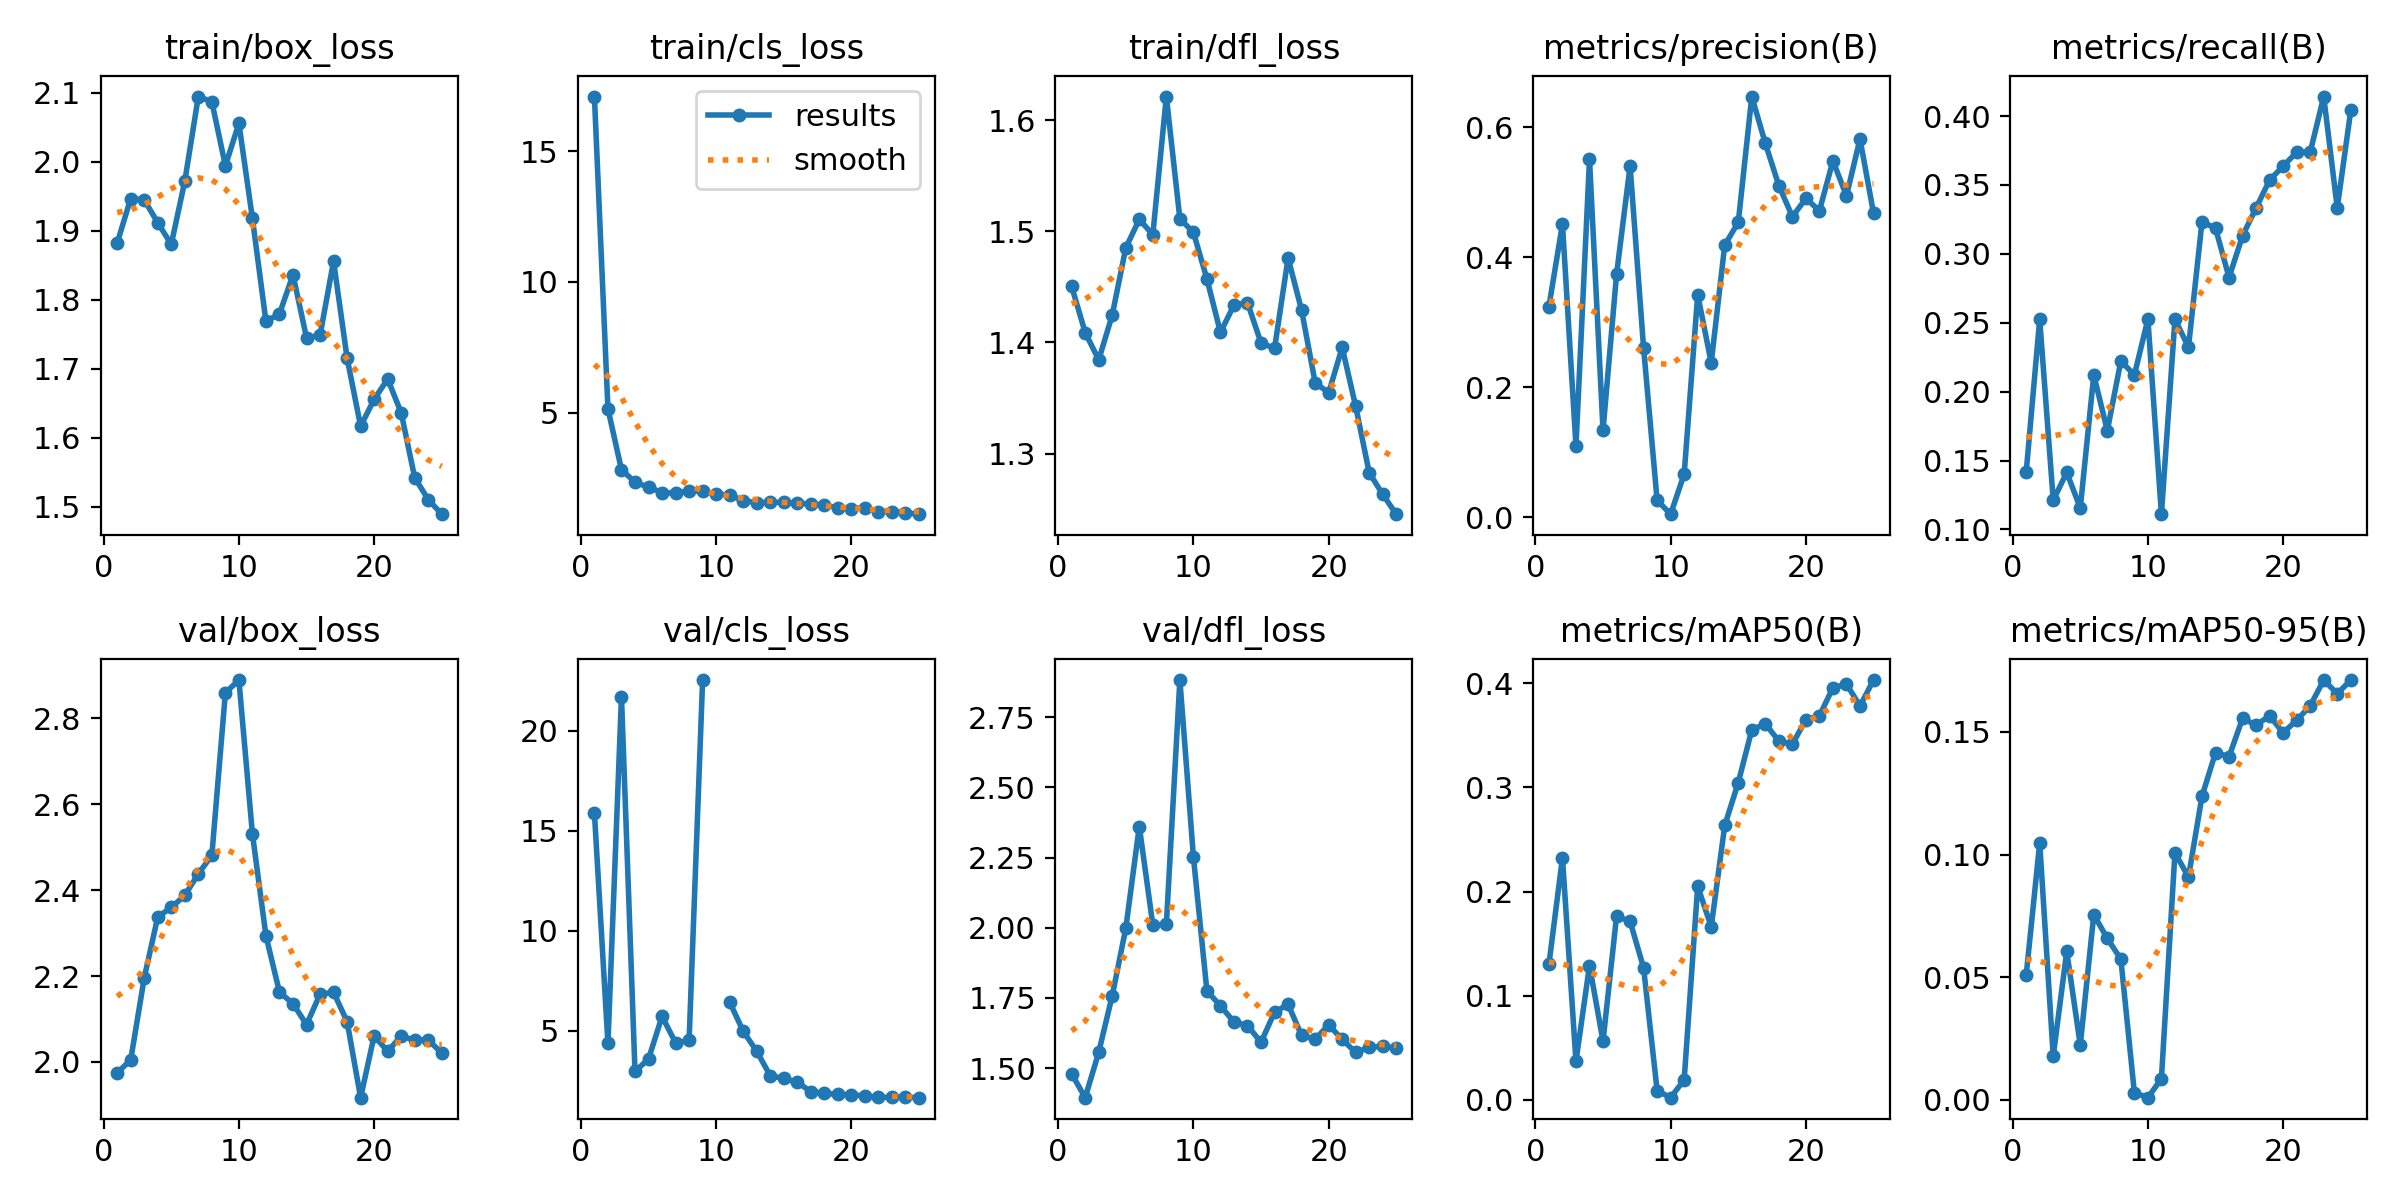

In [10]:
# 1. Display results plot (loss and metrics over epochs)
results_plot = f'{results_dir}/results.png'

if os.path.exists(results_plot):
    print("--- Training Metrics ---")
    display(Image(filename=results_plot, width=800))
else:
    print("results.png not found in the specified directory.")

--- Validation Predictions ---


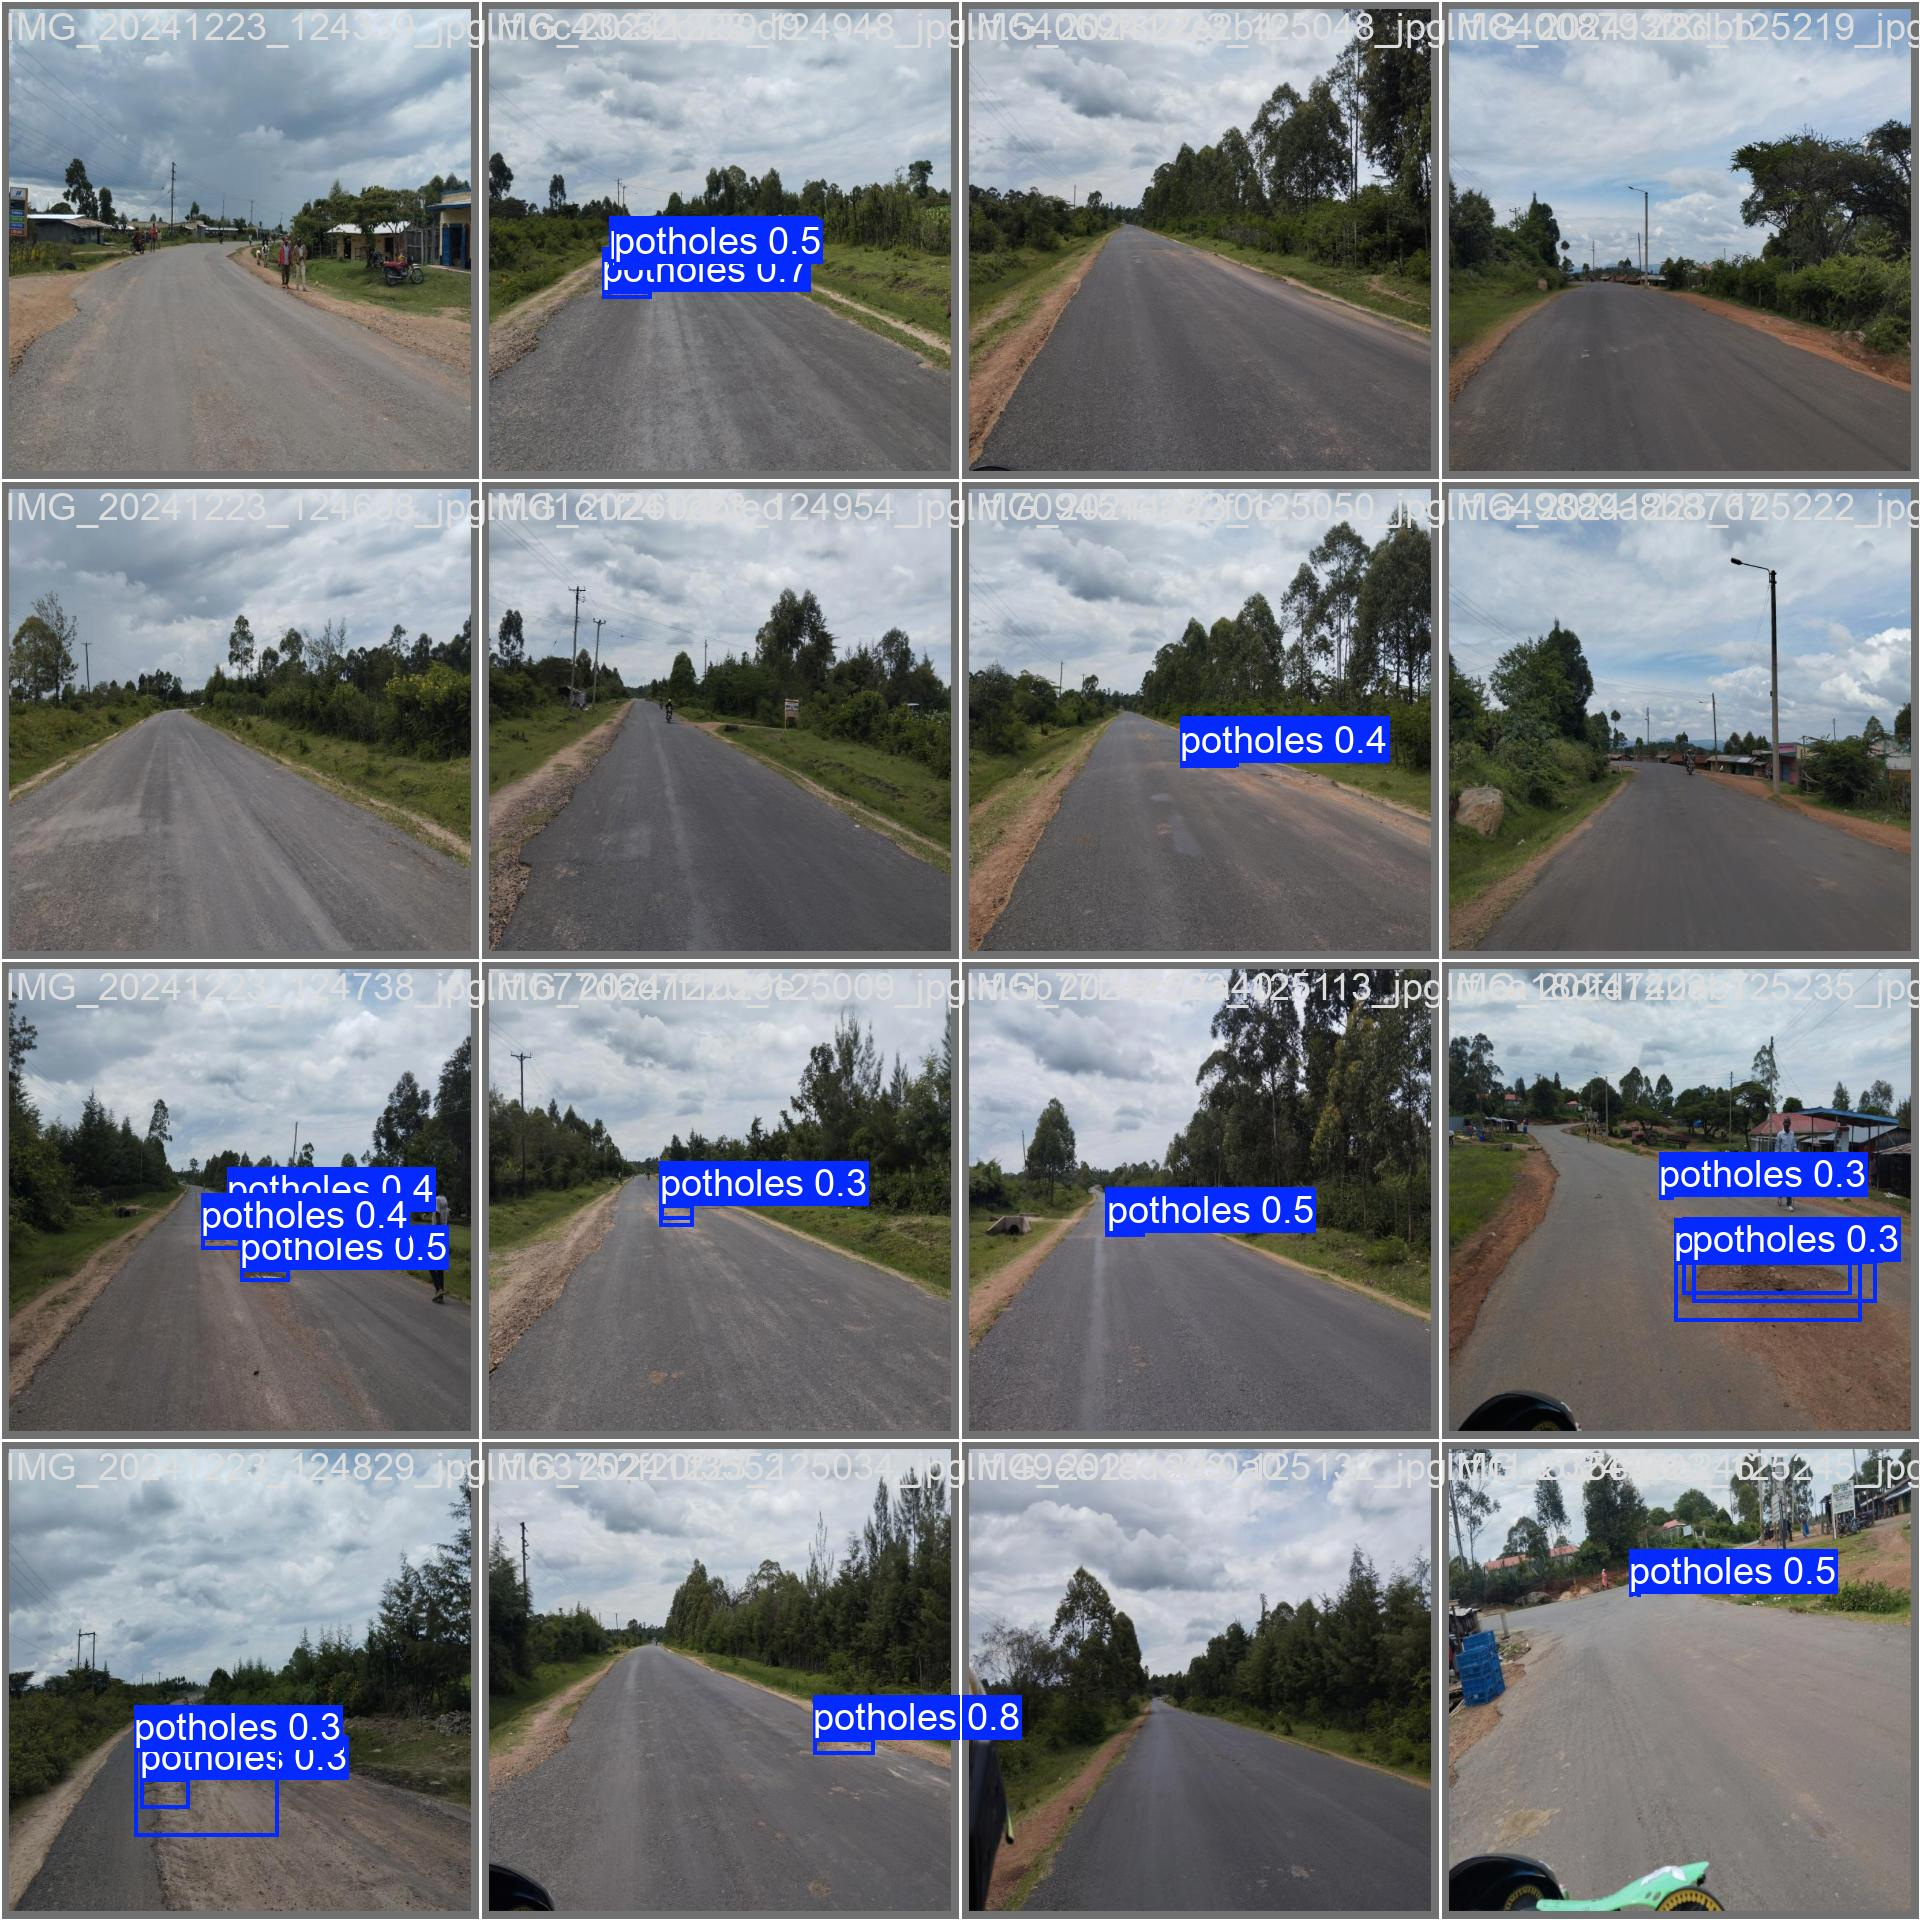

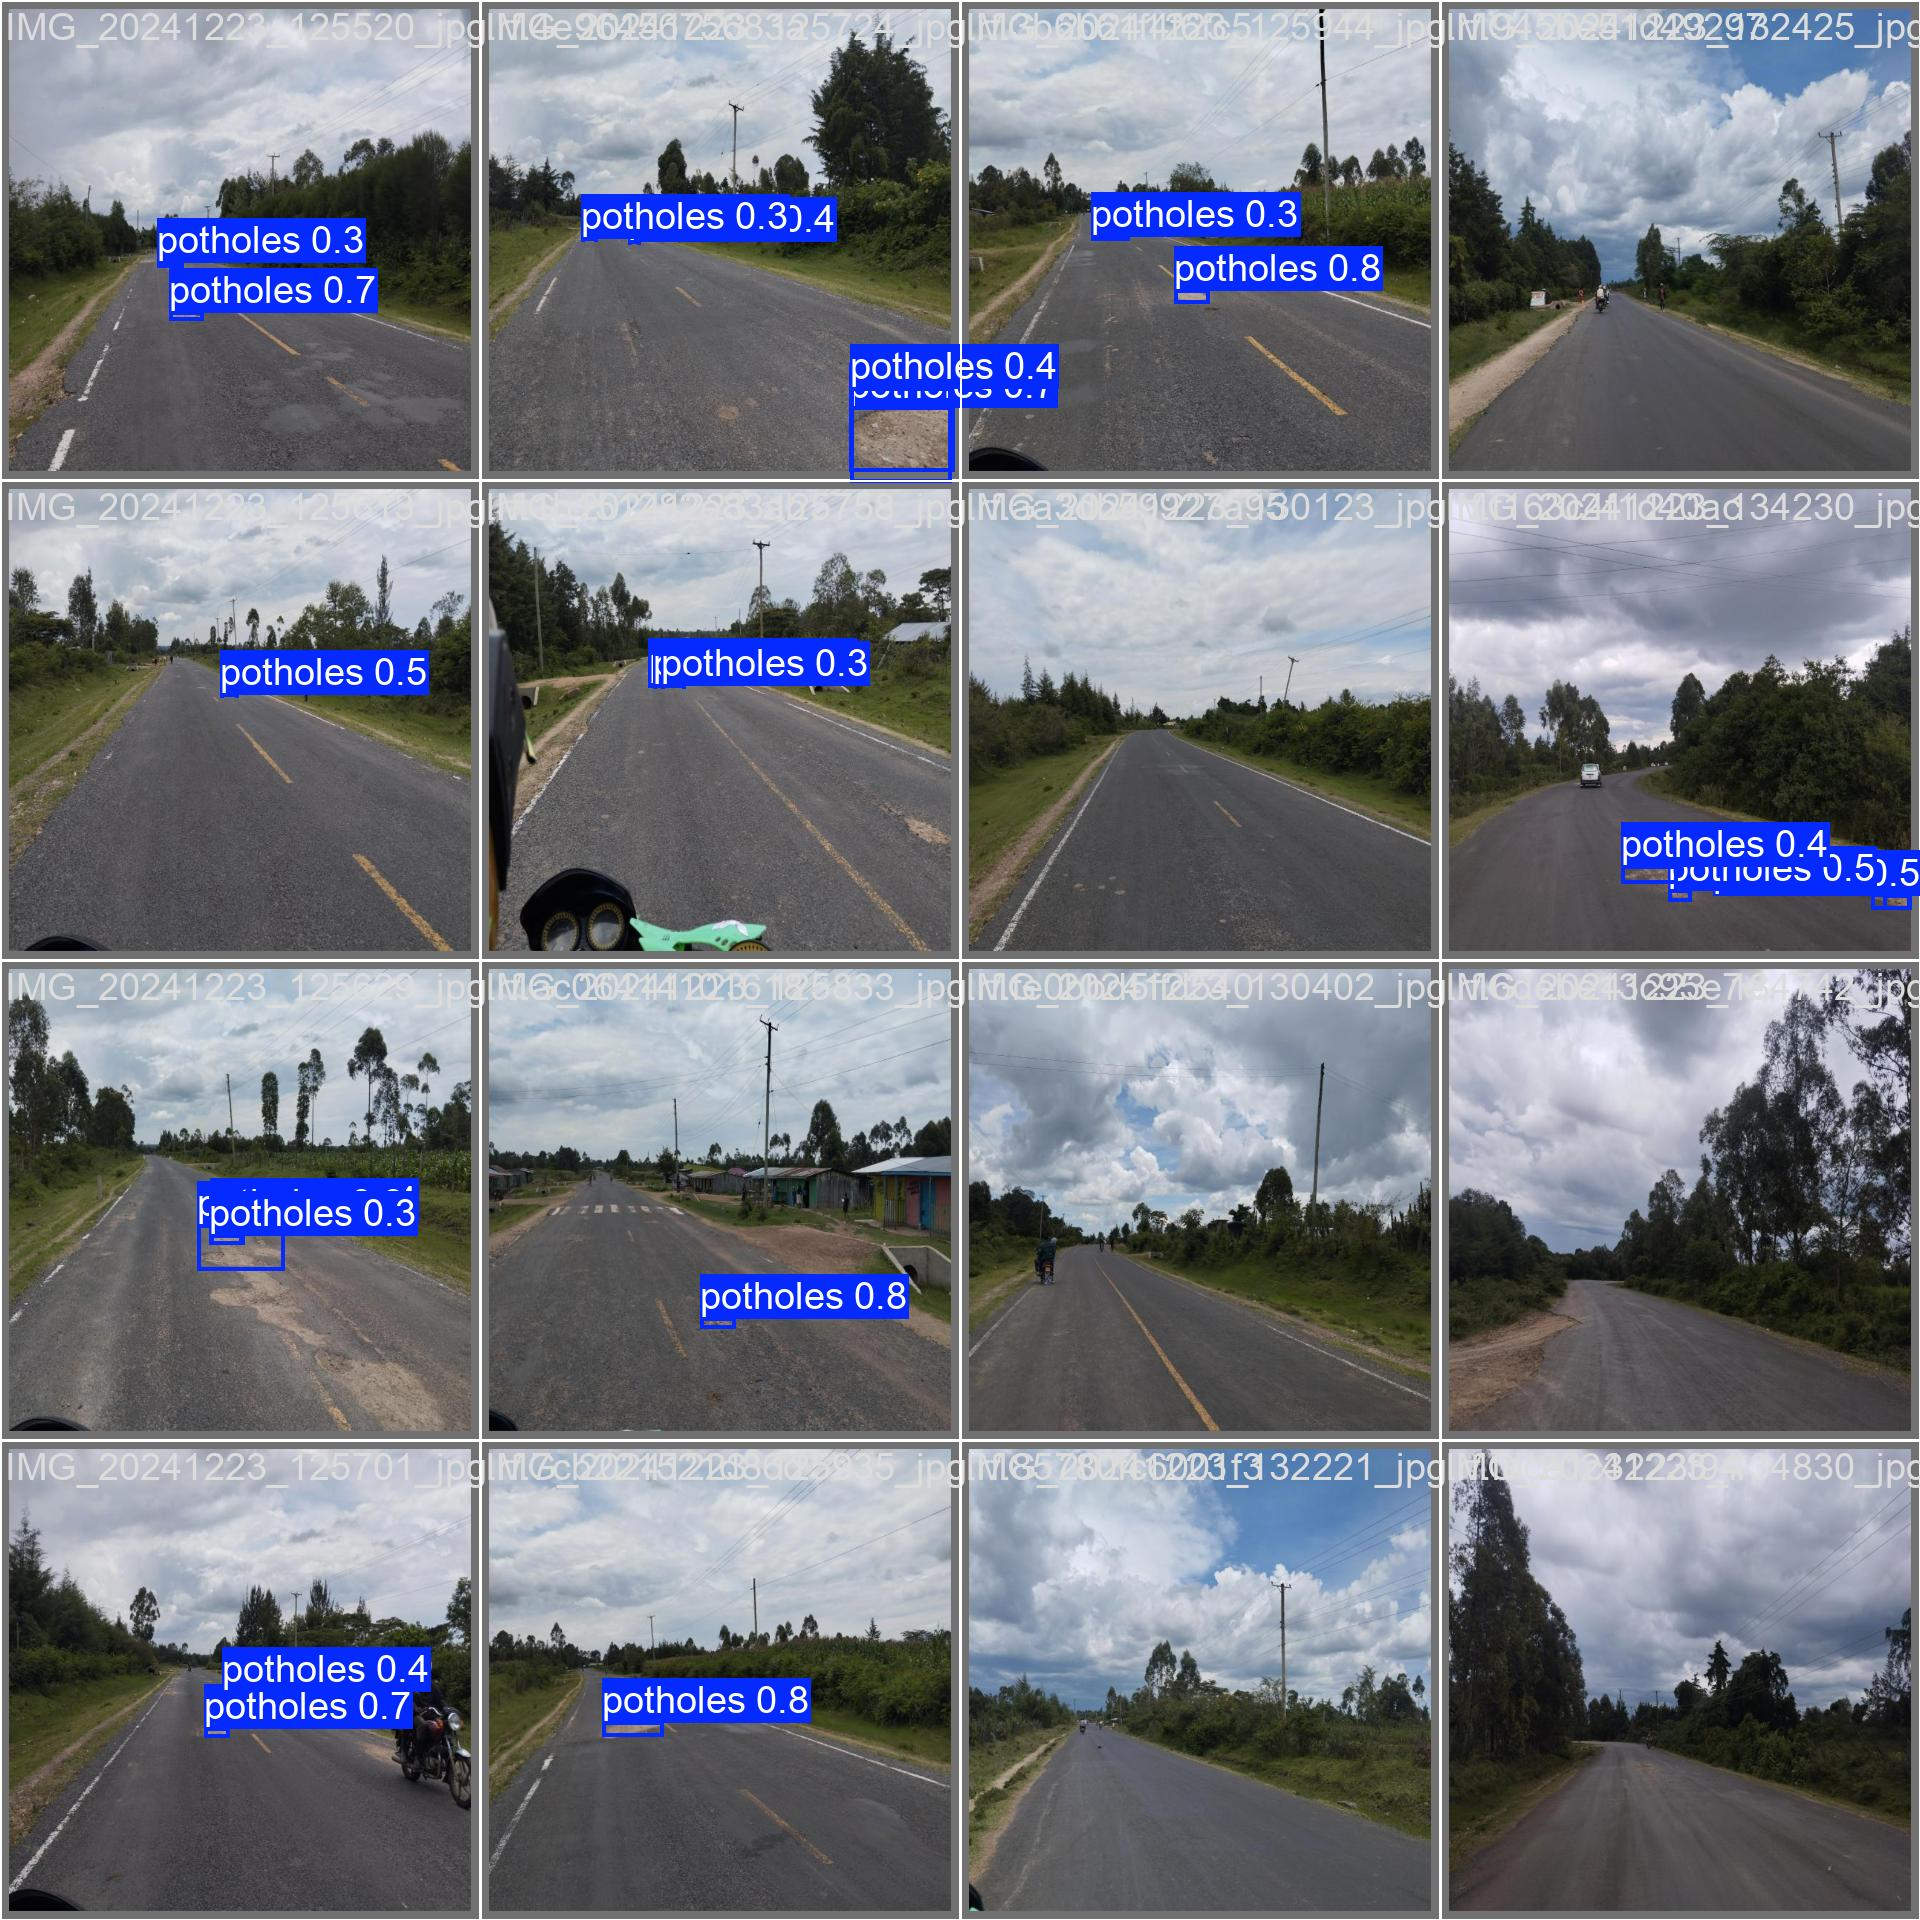

In [11]:
# 3. Display validation predictions
print("--- Validation Predictions ---")
found_images = False

for i in range(10):
    pred_path = f'{results_dir}/val_batch{i}_pred.jpg'
    if os.path.exists(pred_path):
        display(Image(filename=pred_path, width=800))
        found_images = True

if not found_images:
    print("No validation prediction batches (val_batchX_pred.jpg) found.")

--- Confusion Matrix ---


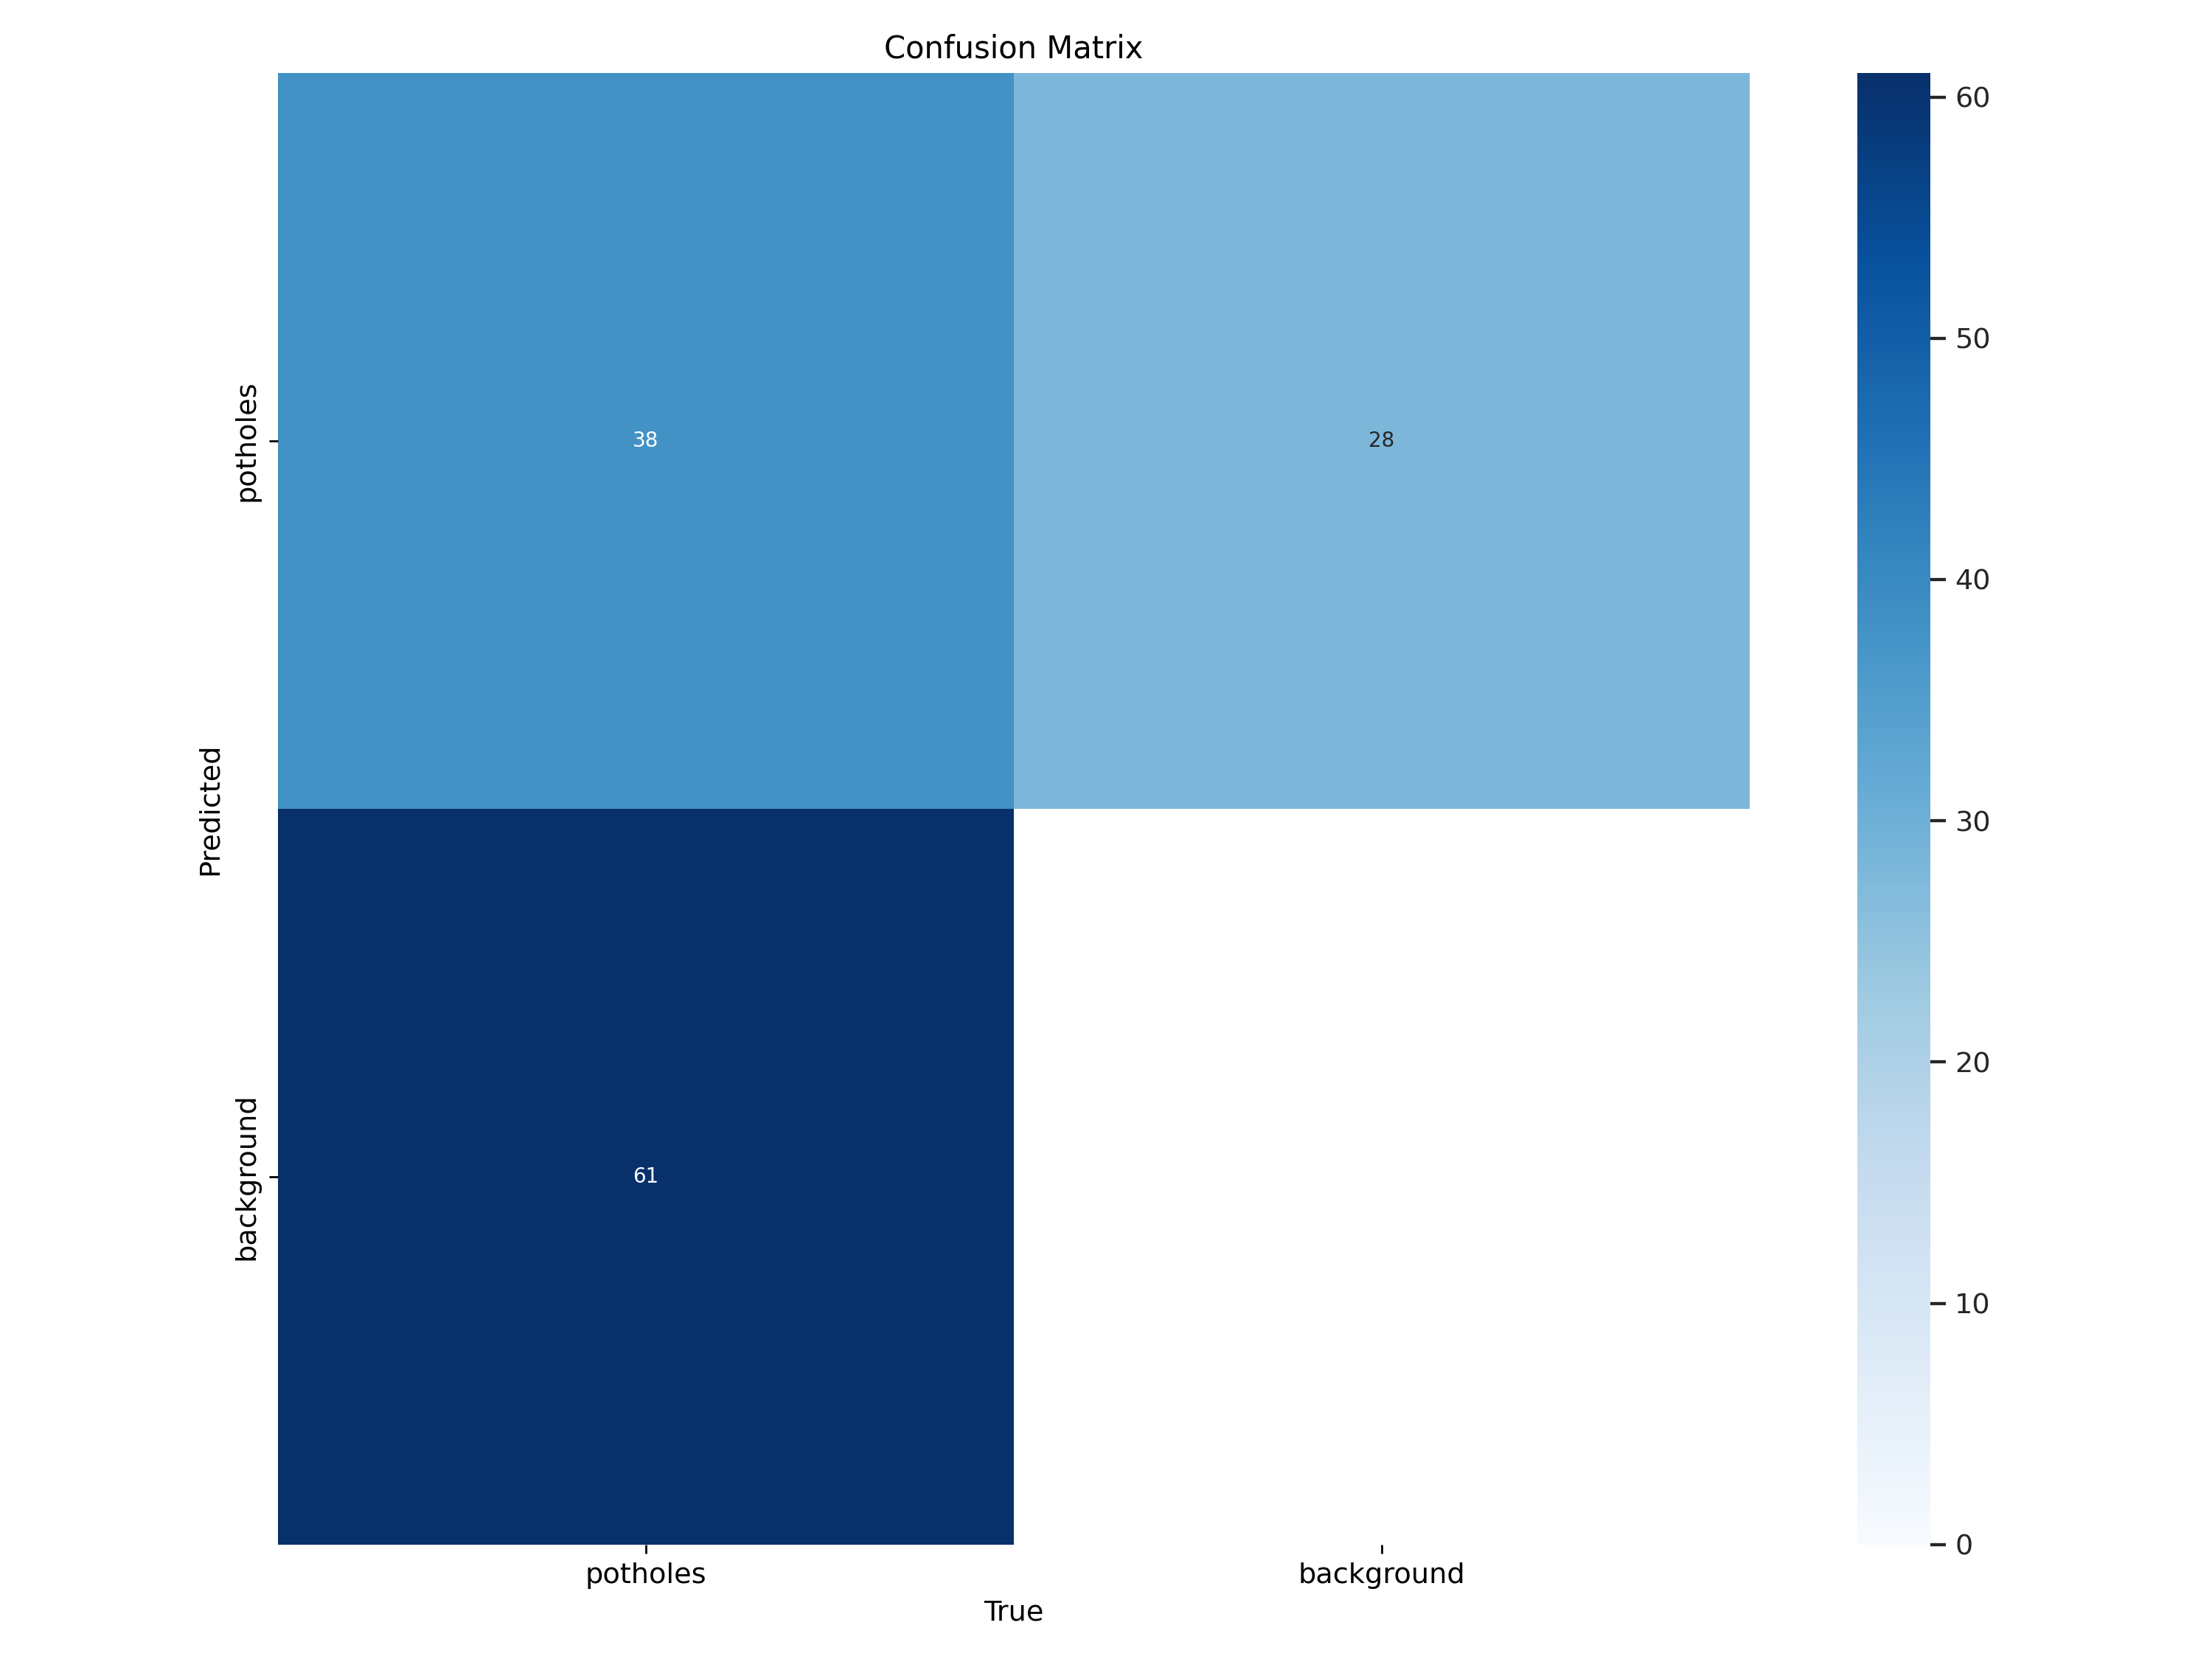

In [12]:
# 2. Display confusion matrix
confusion_matrix = f'{results_dir}/confusion_matrix.png'

if os.path.exists(confusion_matrix):
    print("--- Confusion Matrix ---")
    display(Image(filename=confusion_matrix, width=600))
else:
    print("confusion_matrix.png not found in the specified directory.")

In [13]:
#!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

### Data Quality Visualization

---

## Phase 3: Address - Question Answering

The third phase involves answering specific questions using the assessed data, including modeling and visualization.

Running inference on test images...

image 1/26 /content/chepalungu-1/test/images/IMG_20241223_124318_jpg.rf.2a7165695765e7435a7d2a251f6ca041.jpg: 800x800 (no detections), 22.2ms
image 2/26 /content/chepalungu-1/test/images/IMG_20241223_124512_jpg.rf.3f09f5cf532a0931c69233607209b71a.jpg: 800x800 1 potholes, 22.2ms
image 3/26 /content/chepalungu-1/test/images/IMG_20241223_124730_jpg.rf.b6f73c67e54a4d33d39df0e232a5f95f.jpg: 800x800 (no detections), 22.2ms
image 4/26 /content/chepalungu-1/test/images/IMG_20241223_124732_jpg.rf.bfa5133b5972689508e32546759cbb22.jpg: 800x800 (no detections), 22.1ms
image 5/26 /content/chepalungu-1/test/images/IMG_20241223_124734_jpg.rf.f45e3c80d9a8513fd6edb1d4bf7d1b9b.jpg: 800x800 2 potholess, 22.1ms
image 6/26 /content/chepalungu-1/test/images/IMG_20241223_124927_jpg.rf.7533d31f3e831d06fd9b2dbae8b18e91.jpg: 800x800 2 potholess, 22.2ms
image 7/26 /content/chepalungu-1/test/images/IMG_20241223_124953_jpg.rf.7a60a53cb3a4529454b9da650e7489bd.jpg: 800x800 (no de

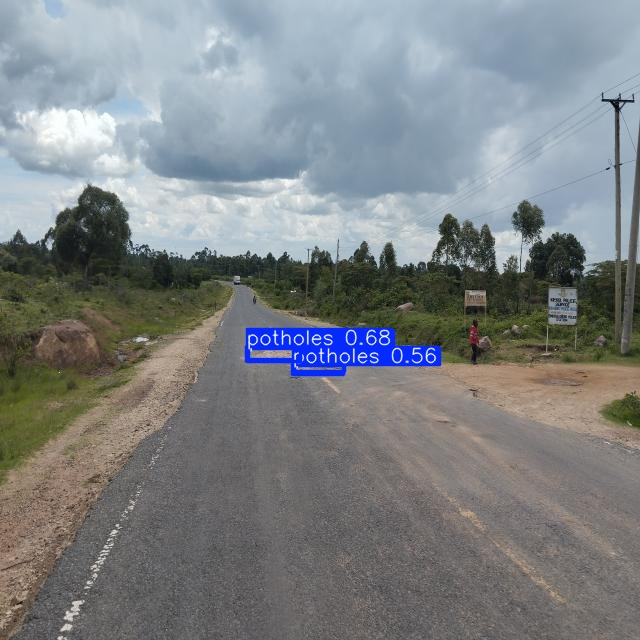

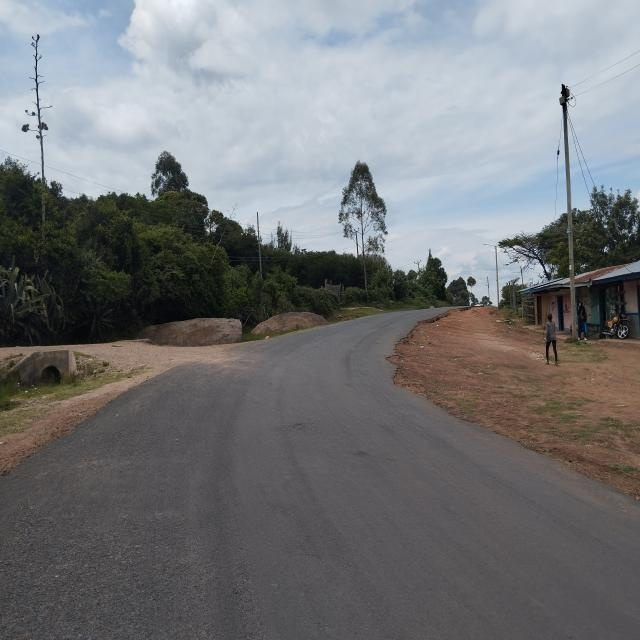

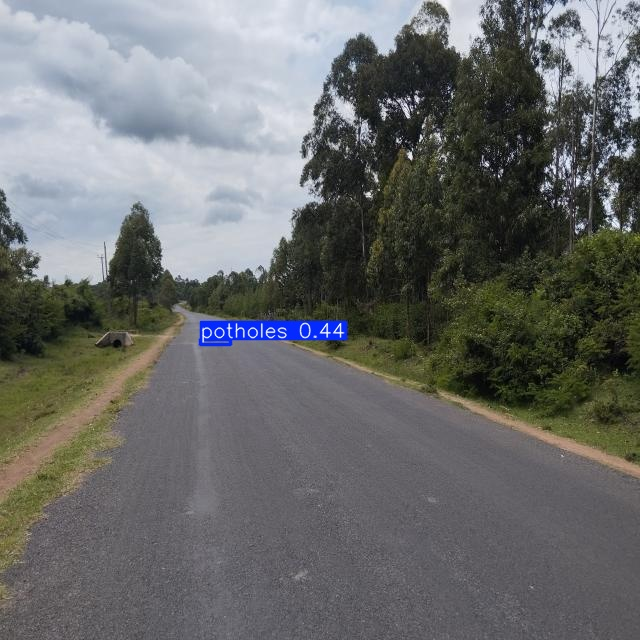

In [14]:
# ==========================================
# Phase 3: Address - Inference on Unseen Data
# ==========================================
import glob
import random
from ultralytics import YOLO
from IPython.display import display, Image

# 1. Load your newly trained "best" model
model = YOLO('runs/detect/train/weights/best.pt')

# 2. Define the path to your unseen test images
test_images_path = '/content/chepalungu-1/test/images'

# 3. Run inference!
# 'save=True' tells YOLO to draw the bounding boxes and save the images
# 'conf=0.25' tells it to only show boxes it is at least 25% confident about
print("Running inference on test images...")
results = model.predict(source=test_images_path, save=True, conf=0.25)

# 4. Display a few random predictions
# YOLO usually saves predictions in a folder called 'runs/detect/predict'
predict_dir = 'runs/detect/predict'
predicted_images = glob.glob(f'{predict_dir}/*.jpg')

if predicted_images:
    print(f"\n--- Displaying Random Predictions ---")
    # Select up to 3 random images from the prediction folder
    sample_images = random.sample(predicted_images, min(3, len(predicted_images)))
    for img_path in sample_images:
        display(Image(filename=img_path, width=800))
else:
    print("No predicted images found. Check your paths!")

### Analysis Results Visualization

---

## Next Steps: Customizing Your Analysis

### 1. Update Configuration
Edit `fynesse/defaults.yml` to point to your data sources:

### 2. Implement Your Data Access
Modify `fynesse/access.py` to load your specific data:

### 3. Add Data Assessment Logic
Enhance `fynesse/assess.py` with your quality checks:

### 4. Implement Analysis Functions
Customize `fynesse/address.py` for your specific questions: